# INP浓度的时间序列

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import curve_fit

In [ ]:
# 数据读取与预处理
df = pd.read_csv(r'D:\Coding\master0_2025\Lanzhou_cfdc\N_INP(202409-202509)v2.0.csv')
## 将日期设为索引
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
## 增加1列
def activation_temperature(temp: pd.Series):
    if abs(temp - (-15)) < 2.5:
        return -15
    elif abs(temp - (-20)) < 2.5:
        return -20
    elif abs(temp - (-25)) < 2.5:
        return -25
    elif abs(temp - (-30)) < 2.5:
        return -30
    elif abs(temp - (-35)) < 2.5:
        return -35
    else:
        return np.nan
df['T_a(°C)'] = df['T_inp(°C)'].apply(activation_temperature)
## 解决不显示的问题：中文设置为宋体格式
plt.rcParams['font.family'] = ["Times New Roman", 'SimSun']
## 数据预处理（质量控制）
df_selected = df[df['N_inp_net(#/L)'] > 0]
df_selected = df_selected[df_selected['SS_w'] > 4]# 师兄认为需要剔除 SS_w<4 的数据
#df_selected = df_selected[df_selected['season'] == 'Winter']
print(f"总点数量: {df.shape[0]}")
print(f"有效点数量: {df_selected.shape[0]}")
print(f"无效点数量: {df.shape[0] - df_selected.shape[0]}") 

总点数量: 4371
有效点数量: 3143
无效点数量: 1228


In [ ]:
def is_extreme(series):
    lower_bound = series.quantile(0.01)
    upper_bound = series.quantile(0.99)
    return (series < lower_bound) | (series > upper_bound)

In [8]:
def is_outlier(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 3 * iqr
    upper_bound = q3 + 3 * iqr
    return (series < lower_bound) | (series > upper_bound)

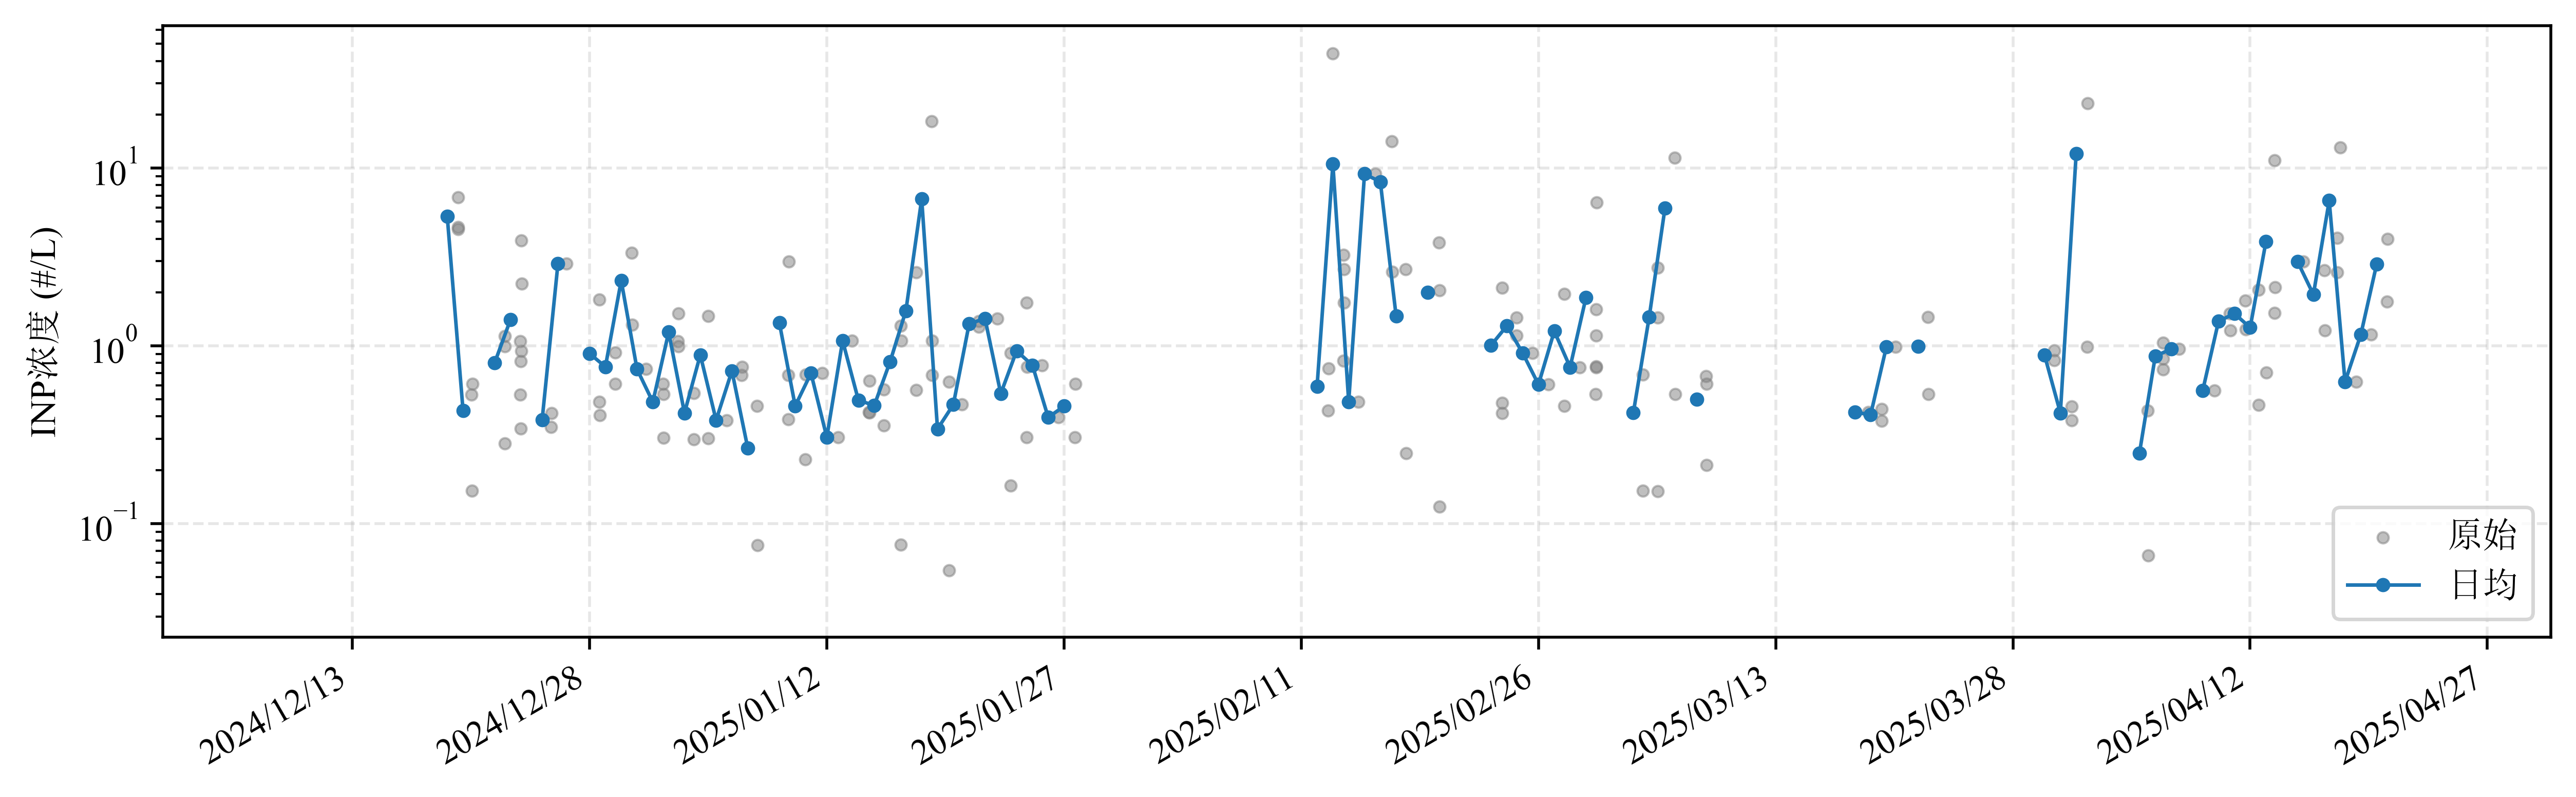

In [ ]:
# 寻找离群点在时间序列中的位置

temp = -15
df_selected = df.where(abs(df['T_inp(°C)'] - temp) < 2.5).dropna()
df_selected = df_selected[df_selected['N_inp_net(#/L)'] > 0]
N_inp = df_selected['N_inp_net(#/L)']
outliers = df_selected[is_outlier(N_inp)]
N_inp_day = N_inp.resample('D').mean()

fig, ax = plt.subplots(figsize=(12, 3.5), dpi=500)

# 给四季添加背景色
season_colors = {
    'Spring': 'lightskyblue',
    'Summer': 'lightgreen',
    'Autumn': 'moccasin',
    'Winter': 'lavender'
}
season_series = df_selected['season']
#print(season_series)
season_blocks = season_series.ne(season_series.shift()).cumsum()
#print(season_blocks)
#added_labels = set()
#for _, block in season_series.groupby(season_blocks):
#    start, end = block.index.min(), block.index.max()
#    season_name = block.iloc[0]
#    color = season_colors.get(season_name, 'lightgray')
#    #label = season_name if season_name not in added_labels else None
#    ax.axvspan(start, end, color=color, alpha=0.15)
#    #added_labels.add(season_name)

ax.scatter(N_inp.index, N_inp.values, c='gray', s=10, alpha=0.5, label='原始', linewidth=0.6)
ax.plot(N_inp_day.index, N_inp_day.values, marker='o', linestyle='-', markersize=3, label='日均', linewidth=1)
#ax.scatter(outliers.index, outliers['N_inp_net(#/L)'], c='red', s=10, label='离群点', linewidth=0.6, edgecolors='black', zorder=5)

#ax.xaxis.set_major_locator(mdates.MonthLocator())
#ax.set_xlim(N_inp.index.min(), N_inp.index.max())

#ax.set_xlim(pd.Timestamp('2024-09-01'), pd.Timestamp('2024-09-13'))
#ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

ax.set_xlim(pd.Timestamp('2024-12-01'), pd.Timestamp('2025-05-01'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=15))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y/%m/%d"))
#ax.set_xlim(pd.Timestamp('2024-12-08'), pd.Timestamp('2024-12-14')) # 如果你想限制显示某几天，可以取消注释这一行

ax.set_ylabel('INP浓度 (#/L)')
ax.set_yscale('log')

ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc='lower right')
fig.autofmt_xdate()   # 自动旋转日期标签

#plt.show()
#plt.savefig(r"C:\Users\admin\Desktop\temp\1.png", dpi=500)